In [1]:
from explore_import import  *
import ionbot_preprocess as io
import data_preprocess as dt
import hpp_checker as hpp
import data_preprocess as dt
import pyteomics.auxiliary as aux
import ast
import tpp_preprocess as tpp

warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
#base directories

root="/project/def-marie87/vvshazia/pride_reanalysis/CompOmics/oui-discovery"
processed_dir=f"{root}/oui-discovery-vv-data/processed/20251015-oui-discovery-ionbot-results"
# get processed files
processed_paths=dt.list_files(processed_dir)
# leave only non-entrapment and open search, only search files
tmp = processed_paths.copy()
for parent, files in processed_paths.items():
    if '-closed' in parent or '-entrap' in parent:
        del tmp[parent]
        continue
    if not any( 'group-walk-output.csv' in f for f in files):
        del tmp[parent]
processed_paths = tmp

# where to save pickles
results_dir = f"{root}/oui-discovery-vv-data/pickles"

20251015-oui-discovery-ionbot-results/
    PXD005833.v0.11.4/
        openprot-x-trembl-filt-global-outerjoin.csv
        PXD005833-opensearch-x-closedsearch-filt-global.csv.gz
        Metadata_PXD005833.v0.11.4-openprot.txt
        ID-rate-df-filt-hybrid.csv
        ID-rate-df-filt-False.csv
        Metadata_PXD005833.v0.11.4-canon.txt
        Metadata_PXD005833.v0.11.4-trembl.txt
        PXD005833-opensearch-x-closedsearch-filt-global-outerjoin.csv.gz
        openprot-x-trembl-filt-global.csv
        ID-rate-df-filt-custom.csv
        ID-rate-df-filt-global.csv
        ID-rate-df-filt-groupwalk.csv
        PXD005833.v0.11.4-canon/
            PXD005833.v0.11.4-canon-combined-features.csv.gz
            combined-results-w-qvalues.csv.gz
            AM15-canon/
                ionbot.first.proteins.csv
                sample-protein-inference-input.pout
                group-walk-output-peptide-vv.csv
                ionbot.features.csv
                ionbot.first.csv
                

In [3]:
psm_filt = []
for parent, files in processed_paths.items():
    if ".ipynb_checkpoints" in parent: continue
    for file in files:
        if file == 'group-walk-output.csv': #-db
            spectrum_file = '-'.join(parent.split('/')[-1].split('-')[:-1])
            search_database = parent.split('/')[-1].split('-')[-1]
            # ONLY OP
            if search_database != 'openprot': continue
            dataset = parent.split('/')[-2].split('-')[0]
            data = pd.read_csv(os.path.join(parent, file))
            #data['spectrum_file'] = spectrum_file
            data['search_database'] = search_database
            data['dataset'] = dataset
            # from Enrico
            # fixes issue with some files being .RAW and other being .raw
            data.spectrum_file = data.spectrum_file.apply(lambda x: x.split('.')[0])
            # in some mgf files the 'spectrum title' includes the file name, making the spectrum title unique.
            # when the file name is NOT included, spectrum titles are NOT unique, and this can mess up some analysis.
            data.spectrum_title = data.spectrum_file + ':' + data.spectrum_title.apply(lambda x: x.split(':')[-1])
            psm_filt += [data]
psm_filt = pd.concat(psm_filt)
# NOTE: decoys are retained
psm_filt = psm_filt[(psm_filt['q.value'] < 0.01)&(psm_filt['isCanonical'] != 'Contam')]

# str to list
psm_filt['proteins'] = psm_filt['proteins'].apply(lambda x: x.split(';'))
# indicate proteotypic peptides
psm_filt['isProteotypic'] = psm_filt['proteins'].apply(lambda x: len(x)==1)
# peptide class
psm_filt["peptide_class"]=psm_filt["proteins"].apply(tpp.classify_peptide_tpp)

In [4]:
root='/project/def-marie87/vvshazia/pride_reanalysis/CompOmics/oui-discovery/oui-discovery-vv-data/processed/20251015-oui-discovery-ionbot-results'
files = [f'{root}/PXD005833.v0.11.4/PXD005833.v0.11.4-openprot/PXD005833.v0.11.4-openprot-combined-features.csv.gz',
        f'{root}/PXD002057.v0.11.4/PXD002057.v0.11.4-openprot/PXD002057.v0.11.4-openprot-combined-features.csv.gz',
        f'{root}/PXD014258.v0.11.4/PXD014258.v0.11.4-openprot/PXD014258.v0.11.4-openprot-combined-features.csv.gz']
data=pd.concat([pd.read_csv(f) for f in files])

In [5]:
psm_filt.columns

Index(['ionbot_match_id', 'spectrum_title', 'scan', 'spectrum_file',
       'precursor_mass', 'peptide_mass', 'observed_retention_time', 'charge',
       'database_peptide', 'matched_peptide', 'modifications',
       'unexpected_modification', 'database', 'psm_score', 'proteins',
       'is.decoy', 'q.value', 'leadprot', 'protein_classes', 'isCanonical',
       'isModified', 'custom_q', 'isTarget', 'FDRGroup', 'group_qval',
       'search_database', 'dataset', 'isProteotypic', 'peptide_class'],
      dtype='object')

In [6]:
data.columns

Index(['ionbot_match_id', 'spectrum_title', 'scan', 'spectrum_file',
       'by-count', 'b-count', 'y-count', 'all-count', 'by-explained',
       'b-explained', 'y-explained', 'all-explained',
       'by-intensity-pattern-correlation', 'top_tag_rank_nterm',
       'top_tag_rank_cterm', 'top_tag_rank', 'predicted_retention_time',
       'retention_time_error_adjusted'],
      dtype='object')

In [7]:
# merge psm and  features
data = data.merge(psm_filt, on=['ionbot_match_id', 'spectrum_title', 'scan', 'spectrum_file'], how='left')

In [8]:
def get_modst(x):
    n_tot = len(x)
    n_mod = len(x[x['modifications']!='Unmodified'])
    n_unmod = len(x[x['modifications']=='Unmodified'])
    if n_tot == n_unmod:
        return "Unmod"
    elif n_tot == n_mod:
        return "OnlyMod"
    else:
        return "Both"

In [9]:
modst = data.groupby(['spectrum_file','database_peptide']).apply(get_modst)

In [10]:
data = data.merge(modst.to_frame().reset_index(), on=['spectrum_file','database_peptide'], how='left')

In [11]:
data[~data[0].isna()][['spectrum_file','by-intensity-pattern-correlation',0]].head()

,spectrum_file,by-intensity-pattern-correlation,0
1,AM10,0.9590,Both
2,AM10,0.8909,Both
6,AM10,0.9667,Unmod
9,AM10,0.8336,Both
10,AM10,0.8043,Unmod


Text(0.5, 1.0, 'Average per-sample ions intensity correlation\nof experimental spectra with predictions by MS2PIP')

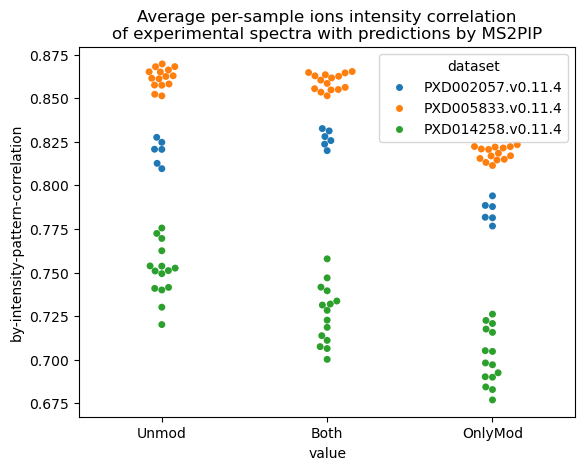

In [12]:
a = data[~data[0].isna()].groupby(['dataset','spectrum_file',0])['by-intensity-pattern-correlation'].apply(np.mean).reset_index()
a.columns = ['dataset','spectrum_file', 'value', 'by-intensity-pattern-correlation']
sns.swarmplot(data=a,x='value',y='by-intensity-pattern-correlation',hue='dataset',order=['Unmod','Both','OnlyMod'])
plt.title('Average per-sample ions intensity correlation\nof experimental spectra with predictions by MS2PIP')

PXD002057.v0.11.4 Unmod Both ns
PXD002057.v0.11.4 Both OnlyMod **
PXD002057.v0.11.4 Unmod OnlyMod **
PXD005833.v0.11.4 Unmod Both ns
PXD005833.v0.11.4 Both OnlyMod ***
PXD005833.v0.11.4 Unmod OnlyMod ***
PXD014258.v0.11.4 Unmod Both ***
PXD014258.v0.11.4 Both OnlyMod ***
PXD014258.v0.11.4 Unmod OnlyMod ***


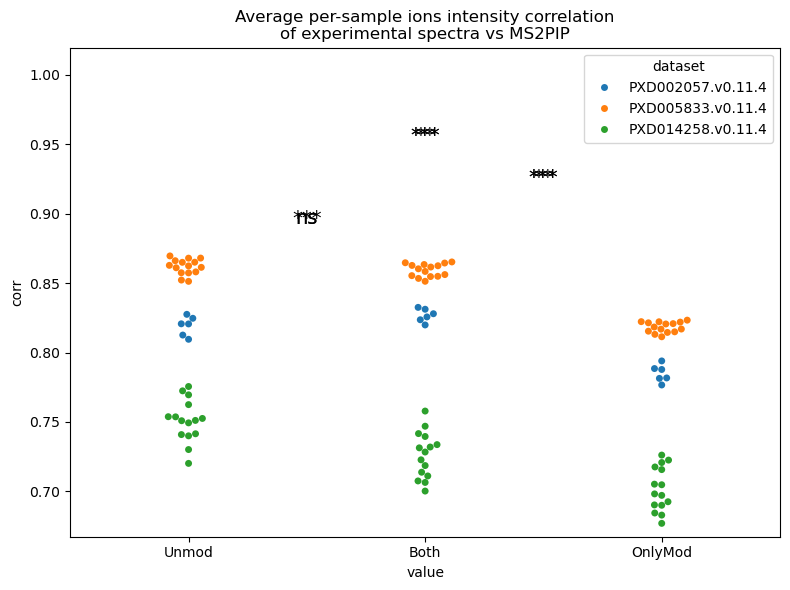

In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

order = ['Unmod','Both','OnlyMod']

# --- Your data preparation ---
a = data[~data[0].isna()] \
    .groupby(['dataset','spectrum_file',0])['by-intensity-pattern-correlation'] \
    .apply(np.mean).reset_index()

a.columns = ['dataset','spectrum_file', 'value', 'corr']

# make sure order is respected
a['value'] = pd.Categorical(a['value'], categories=order, ordered=True)

# --- Plot ---
plt.figure(figsize=(8,6))
sns.swarmplot(data=a, x='value', y='corr', hue='dataset', order=order)
plt.title('Average per-sample ions intensity correlation\nof experimental spectra vs MS2PIP')


# -------------------------------------------------------
#  FUNCTION: significance stars
# -------------------------------------------------------
def p_to_star(p):
    if p < 0.001: return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    else: return 'ns'


# -------------------------------------------------------
#  RUN WILCOXON (MANN–WHITNEY U) PER DATASET
# -------------------------------------------------------

# we annotate above each category pair within each dataset
y_max = a['corr'].max()

for d in a['dataset'].unique():
    df = a[a['dataset'] == d]

    # compare each category pair
    comparisons = [('Unmod','Both'),
                   ('Both','OnlyMod'),
                   ('Unmod','OnlyMod')]

    for i,(g1,g2) in enumerate(comparisons):
        x1 = df[df['value'] == g1]['corr']
        x2 = df[df['value'] == g2]['corr']

        if len(x1) > 0 and len(x2) > 0:
            stat, p = mannwhitneyu(x1, x2, alternative='two-sided')
            star = p_to_star(p)

            # annotation position
            x_pos = (order.index(g1) + order.index(g2)) / 2
            y_pos = y_max + 0.02 + i*0.03   # stack levels
            print(d,g1,g2,star)
            plt.text(x_pos, y_pos, star, ha='center', va='bottom', fontsize=14)

# make space
plt.ylim(None, y_max + 0.15)
plt.tight_layout()
plt.show()


In [ ]:
# RT

In [40]:
data['mod2'] = data.apply(lambda x: 'Unmodified' if x['modifications']=='Unmodified' else 'Modified',axis=1)
a = data[~data['isCanonical'].isna()][['spectrum_file','isCanonical','observed_retention_time','predicted_retention_time','mod2']]
a.columns = ['spectrum_file','isCanonical','observed_retention_time','predicted_retention_time','value']
a['predicted_observed_retention_time_difference'] = a['predicted_retention_time'] - a['observed_retention_time']

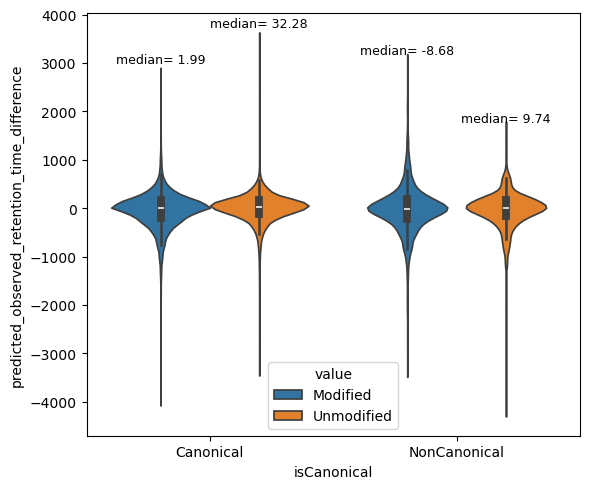

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(6, 5))

sns.violinplot(
    data=a,
    x='isCanonical',
    y='predicted_observed_retention_time_difference',
    hue='value',
    ax=ax
)

# Get unique categories in plotting order
x_levels = a['isCanonical'].unique()
hue_levels = a['value'].unique()

# Determine horizontal offsets used by seaborn for hue splitting
# (works for seaborn >= 0.12)
n_hue = len(hue_levels)
total_width = 0.8
step = total_width / n_hue
offsets = np.linspace(-total_width/2 + step/2, total_width/2 - step/2, n_hue)

# Loop through all combinations
for xi, x_val in enumerate(x_levels):
    for hi, h_val in enumerate(hue_levels):
        group = a[(a['isCanonical'] == x_val) & (a['value'] == h_val)]
        if len(group) == 0:
            continue
        
        median = group['predicted_observed_retention_time_difference'].median()
        y_pos = group['predicted_observed_retention_time_difference'].max()+100

        # x-position of this violin
        x_pos = xi + offsets[hi]

        ax.text(
            x_pos,
            y_pos,
            f"median= {median:.2f}",
            ha='center',
            va='bottom',
            fontsize=9,
            color='black'
        )

plt.tight_layout()
plt.show()


In [42]:
import itertools
import pandas as pd
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

# your numeric column
value_col = 'predicted_observed_retention_time_difference'

# create combined grouping label
a['group'] = list(zip(a['isCanonical'], a['value']))

# get distinct groups
groups = a['group'].unique()

results = []

# generate all pairwise combinations
for g1, g2 in itertools.combinations(groups, 2):
    x = a.loc[a['group'] == g1, value_col]
    y = a.loc[a['group'] == g2, value_col]

    # Mann–Whitney U test
    u_stat, p_mw = mannwhitneyu(x, y, alternative='two-sided')

    results.append({
        'group1': g1,
        'group2': g2,
        'n1': len(x),
        'n2': len(y),
        'mannwhitney_p': p_mw,
    })

# convert to DataFrame
df_results = pd.DataFrame(results)

# correct for multiple testing (BH/FDR preferred)
df_results['mw_adj_p'] = multipletests(df_results['mannwhitney_p'], method='fdr_bh')[1]

df_results['*'] = df_results['mw_adj_p'] < 0.05
df_results['**'] = df_results['mw_adj_p'] < 0.01
df_results['***'] = df_results['mw_adj_p'] < 0.001


In [43]:
df_results

,group1,group2,n1,n2,mannwhitney_p,mw_adj_p,*,**,***
0,"(Canonical, Modified)","(Canonical, Unmodified)",114617,198625,3.034866e-256,1.820920e-255,True,True,True
1,"(Canonical, Modified)","(NonCanonical, Modified)",114617,8392,4.863514e-01,4.863514e-01,False,False,False
2,"(Canonical, Modified)","(NonCanonical, Unmodified)",114617,1895,2.340250e-01,2.808300e-01,False,False,False
3,"(Canonical, Unmodified)","(NonCanonical, Modified)",198625,8392,6.683672e-32,2.005101e-31,True,True,True
4,"(Canonical, Unmodified)","(NonCanonical, Unmodified)",198625,1895,1.461877e-05,2.923753e-05,True,True,True
5,"(NonCanonical, Modified)","(NonCanonical, Unmodified)",8392,1895,1.534836e-01,2.302254e-01,False,False,False


In [45]:
a.groupby(['isCanonical','value'])['predicted_observed_retention_time_difference'].apply(np.median)

isCanonical   value     
Canonical     Modified       1.989446
              Unmodified    32.277795
NonCanonical  Modified      -8.682082
              Unmodified     9.744793
Name: predicted_observed_retention_time_difference, dtype: float64

In [54]:
a.groupby(['isCanonical','value']).apply(
    lambda x: (len(x[abs(x['predicted_observed_retention_time_difference'])>1000])/len(x))*100
    )

isCanonical   value     
Canonical     Modified      2.213459
              Unmodified    0.936438
NonCanonical  Modified      5.052431
              Unmodified    2.110818
dtype: float64

In [77]:
bothmod = data[(~data.isCanonical.isna())&(data[0]=='Both')]

In [78]:
unmod = bothmod[bothmod['modifications'] == 'Unmodified']
mods  = bothmod[bothmod['modifications'] != 'Unmodified']

bothmod_merged = unmod.merge(
    mods,
    on=['database_peptide', 'spectrum_file'], 
    suffixes=('_unmod', '_mod')
)

In [79]:
# how different do we expect RT to be beween modified and unmodified peptide?

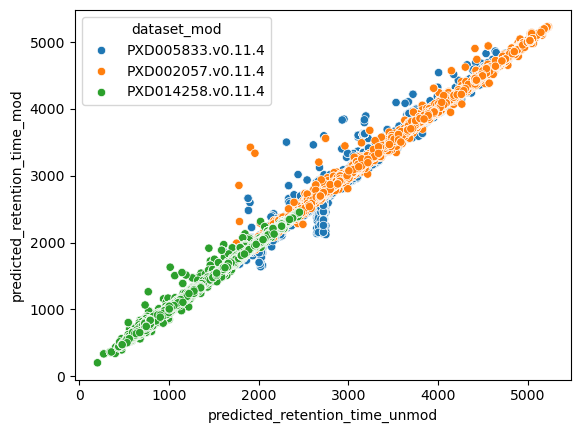

In [80]:
sns.scatterplot(data = bothmod_merged, x='predicted_retention_time_unmod',y='predicted_retention_time_mod',hue='dataset_mod');

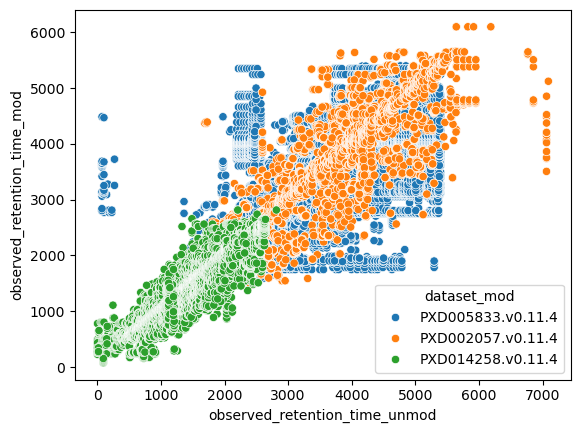

In [81]:
sns.scatterplot(data = bothmod_merged, x='observed_retention_time_unmod',y='observed_retention_time_mod',hue='dataset_mod');

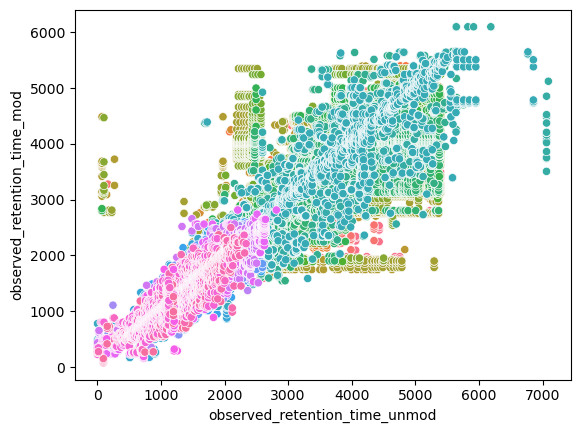

In [84]:
sns.scatterplot(data = bothmod_merged, x='observed_retention_time_unmod',y='observed_retention_time_mod',hue='spectrum_file',legend=False);


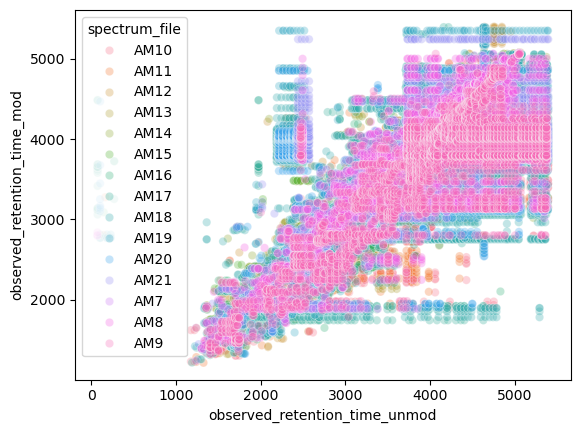

In [88]:
sns.scatterplot(data = bothmod_merged[bothmod_merged.dataset_mod=='PXD005833.v0.11.4'], x='observed_retention_time_unmod',y='observed_retention_time_mod',
                hue='spectrum_file',alpha=0.3);

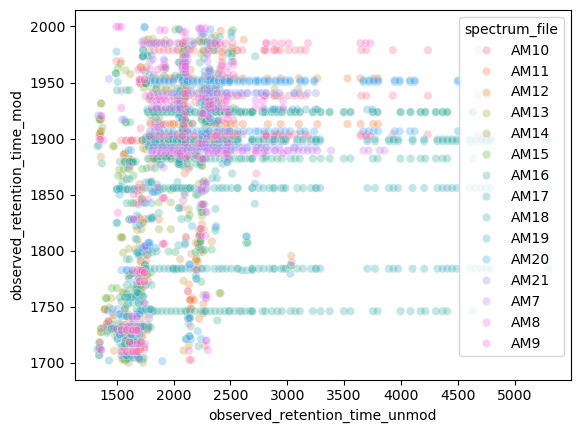

In [90]:
sns.scatterplot(data = bothmod_merged[(bothmod_merged.observed_retention_time_mod<2000)&(bothmod_merged.observed_retention_time_mod>1700)&(bothmod_merged.dataset_mod=='PXD005833.v0.11.4')], 
                x='observed_retention_time_unmod',y='observed_retention_time_mod',
                hue='spectrum_file',alpha=0.3);

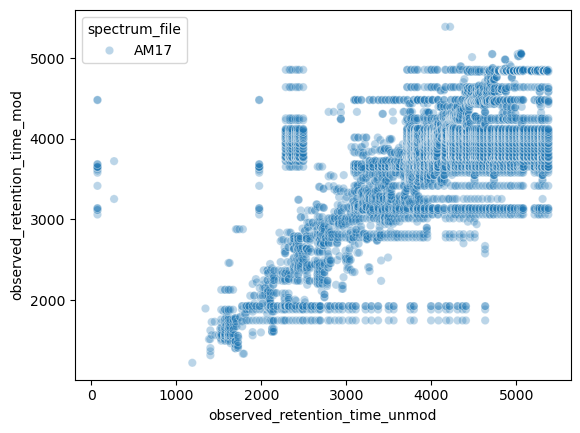

In [111]:
sns.scatterplot(data = bothmod_merged[(bothmod_merged.spectrum_file=='AM17')&(bothmod_merged.dataset_mod=='PXD005833.v0.11.4')], x='observed_retention_time_unmod',y='observed_retention_time_mod',
                hue='spectrum_file',alpha=0.3);

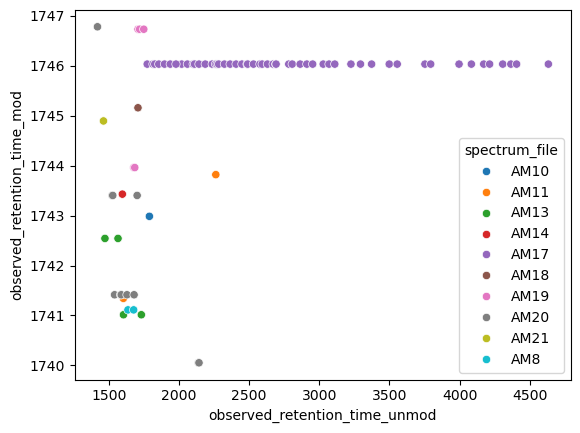

In [94]:
sns.scatterplot(data = bothmod_merged[(bothmod_merged.observed_retention_time_mod<1747)&(bothmod_merged.observed_retention_time_mod>1740)&(bothmod_merged.dataset_mod=='PXD005833.v0.11.4')], 
                x='observed_retention_time_unmod',y='observed_retention_time_mod',
                hue='spectrum_file');

In [97]:
a=bothmod_merged[(bothmod_merged.observed_retention_time_mod<1747)&
        (bothmod_merged.observed_retention_time_mod>1745)&
        (bothmod_merged.dataset_mod=='PXD005833.v0.11.4')&(bothmod_merged.spectrum_file=='AM17')]

In [99]:
a.database_peptide.unique()

array(['AGFAGDDAPR'], dtype=object)

In [104]:
# observed modified just once -- but probably these lines are created always by a limited set of peptides? -- they have a big renge of RT
a.modifications_mod.unique(),a.scan_mod.unique()

(array(['3|[35]Oxidation[F](494.45)_or_2|[35]Oxidation[G](539.80)'],
       dtype=object),
 array([7964]))

In [ ]:
# select rows where the minimal and maximal RT for unmodified peptide is >=1500

In [112]:
a=bothmod_merged[(bothmod_merged.dataset_mod=='PXD005833.v0.11.4')&(bothmod_merged.spectrum_file=='AM17')].copy(deep=True)
b = a.groupby('database_peptide').apply(lambda x: 
                                          abs(x['observed_retention_time_unmod'].max() - x['observed_retention_time_unmod'].min()) >=1000)#.value_counts()
b[b]

database_peptide
ADVDAATLAR                True
AGFAGDDAPR                True
AGLQFPVGR                 True
AVFPSIVGRPR               True
AVFVDLEPTVIDEVR           True
IWHHSFYNELR               True
KDLYANNVMSGGTTMYPGIADR    True
LLLPGELAK                 True
SYELPDGQVITIGNER          True
VAPEEHPTLLTEAPLNPK        True
dtype: bool

In [117]:
# how many modified forms they have? -- when multiple - this where we have many more rows in plot, not 10
a[a.database_peptide.isin(b[b].index.tolist())].groupby('database_peptide').apply(lambda x: len(x.modifications_mod.unique()))

database_peptide
ADVDAATLAR                 1
AGFAGDDAPR                 3
AGLQFPVGR                  1
AVFPSIVGRPR                2
AVFVDLEPTVIDEVR            5
IWHHSFYNELR                1
KDLYANNVMSGGTTMYPGIADR     9
LLLPGELAK                  2
SYELPDGQVITIGNER          36
VAPEEHPTLLTEAPLNPK        16
dtype: int64

In [119]:
# how many charge states? - up to 2 - ok
a[a.database_peptide.isin(b[b].index.tolist())].groupby('database_peptide').apply(lambda x: len(x.charge_unmod.unique()))

database_peptide
ADVDAATLAR                1
AGFAGDDAPR                1
AGLQFPVGR                 1
AVFPSIVGRPR               2
AVFVDLEPTVIDEVR           2
IWHHSFYNELR               2
KDLYANNVMSGGTTMYPGIADR    1
LLLPGELAK                 1
SYELPDGQVITIGNER          2
VAPEEHPTLLTEAPLNPK        2
dtype: int64

In [123]:
# aboundant proteins? - 4 peptide from actine, others desmin, tubulin,histone H2A/B
a[a.database_peptide.isin(b[b].index.tolist())].drop_duplicates('proteins_unmod')[['database_peptide','proteins_unmod','leadprot_unmod']]

,database_peptide,proteins_unmod,leadprot_unmod
31497,AGFAGDDAPR,"[P68133, P63267, P63267-2, A5A3E0, P0CG38, P0C...",P68133
31603,ADVDAATLAR,"[P17661, Q9GZR6, Q45VM7, A5Z217, L7RDA5, Q45VM...",P17661
31662,SYELPDGQVITIGNER,"[P68133, P63267, P63267-2, A5A3E0, Q6S8J3, Q56...",P68133
32458,AVFPSIVGRPR,"[P68133, P63267, P63267-2, A5A3E0, P0CG38, Q6S...",P68133
32557,AVFVDLEPTVIDEVR,"[P68363, Q71U36, Q71U36-2, Q9BQE3, F8VS66, NP_...",P68363
32588,AGLQFPVGR,"[Q6FI13, Q16777, Q8IUE6, Q7L7L0, P0C0S5, Q96QV...",Q6FI13
32598,IWHHSFYNELR,"[P63267, D2JYH4, B4DUI8, II_792627, F6QUT6, C9...",P63267
32660,VAPEEHPTLLTEAPLNPK,"[P68133, P63267, P63267-2, D2JYH4, P68032, B4D...",P68133
32854,LLLPGELAK,"[Q5QNW6, Q5QNW6-2, II_069706, Q16778, Q8N257, ...",Q5QNW6
33673,KDLYANNVMSGGTTMYPGIADR,"[P68133, A0A804HKV3, A6NL76, B7Z6P1, B3KUD3, Q...",P68133


In [ ]:
# OK, probably there are technical issues, like tailing caused by sample load or smth.

In [ ]:
# and how does predictions calibrate it?

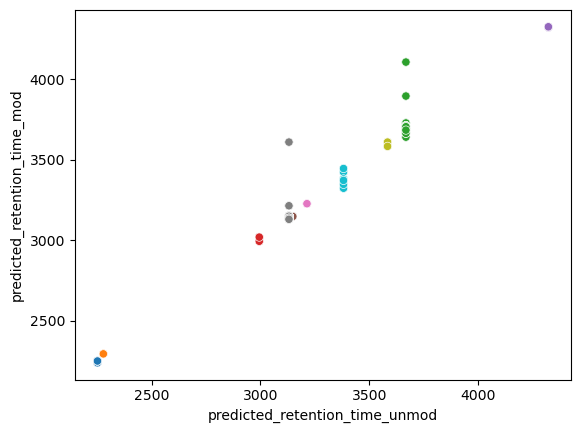

In [125]:
# they are aligned
sns.scatterplot(data = bothmod_merged[(bothmod_merged.database_peptide.isin(b[b].index.tolist()))&
                (bothmod_merged.dataset_mod=='PXD005833.v0.11.4')&(bothmod_merged.spectrum_file=='AM17')],
                x='predicted_retention_time_unmod',y='predicted_retention_time_mod',hue='database_peptide',legend=False);

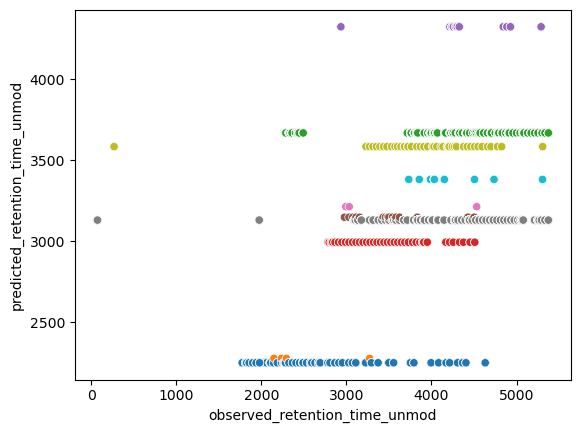

In [128]:
sns.scatterplot(data = bothmod_merged[(bothmod_merged.database_peptide.isin(b[b].index.tolist()))&
                (bothmod_merged.dataset_mod=='PXD005833.v0.11.4')&(bothmod_merged.spectrum_file=='AM17')],
                x='observed_retention_time_unmod',y='predicted_retention_time_unmod',hue='database_peptide',legend=False);

In [148]:
insituPEP = pd.read_csv("./../../../junk/insitu_peptides.csv")

In [136]:
insituPEP[insituPEP.protein_class=='NonCanon'].groupby('protein')['isUnique'].any().value_counts()

isUnique
True     437253
False     29769
Name: count, dtype: int64

In [150]:
from pyteomics import mass

In [155]:
# get monoisotopic mass of peptides
def get_pep_mass(x):
    try:
        res = mass.calculate_mass(sequence=x)
    except:
        res = np.nan
    return res
insituPEP["peptide_mass"] = insituPEP["peptide"].apply(lambda x: get_pep_mass(x))

In [ ]:
THRESH = 186.079312980 #https://proteomicsresource.washington.edu/protocols06/masses.php

# Sort by mass once (very important for efficiency)
insituPEP = insituPEP.sort_values("peptide_mass").reset_index(drop=True)

masses = insituPEP["peptide_mass"].values
n = len(masses)

groups = np.zeros(n, dtype=np.int32)

# Start with group 1
group_id = 1
groups[0] = group_id
group_start_mass = masses[0]

# Group peptides by difference in max mass of 1 aa
for i in range(1, n):
    print(i,(i/n)*100)
    if masses[i] - group_start_mass <= THRESH:
        # same group
        groups[i] = group_id
    else:
        # new group starts
        group_id += 1
        group_start_mass = masses[i]
        groups[i] = group_id

insituPEP["group"] = groups

del groups, masses

In [159]:
len(insituPEP["group"].unique())

25281

In [163]:
def is_one_aa_difference(peptide1, peptide2):    
    # Calculate Hamming distance
    distance = sum(a != b for a, b in zip(peptide1, peptide2))
    # Return True if the difference is exactly 1 amino acid
    return distance == 1

In [172]:
# group peptides of similar length and mass

aa_str = "ACDEFGHIKLMNPQRSTVWY"
insituPEP["unique_NonCanon_1aa_dff_Canon"] = False
results = {}  # store True/False for each noncanon peptide

for (peptide_length, group), df in insituPEP.groupby(["peptide_length","group"]):
    print(group, (group / len(insituPEP["group"].unique()))*100)

    # Split NonCanon and Canon peptides
    noncanon = df[(df.protein_class=='NonCanon') & (df.peptide_class.str.contains("unique_to"))]
    canon = df[~((df.protein_class=='NonCanon') & (df.peptide_class.str.contains("unique_to")))]

    if len(noncanon) == 0:
        continue

    canon_pep_set = set(canon.peptide.unique())  # precompute once per group
    noncanon_pep = noncanon.peptide.unique()

    for nc_pep in noncanon_pep:
        nc_pep_sim = False
        for pos in range(len(nc_pep)):
            for aa in aa_str:
                if nc_pep[pos] == aa:
                    continue  # skip identical AA
                mutated = nc_pep[:pos] + aa + nc_pep[pos+1:]
                if mutated in canon_pep_set:
                    nc_pep_sim = True
                    break
            if nc_pep_sim:
                break
        results[nc_pep] = nc_pep_sim

    # Assign results in one go
#    insituPEP.loc[insituPEP.peptide.isin(results.keys()), "unique_NonCanon_1aa_dff_Canon"] = list(results.values())
#        insituPEP.peptide.map(results)


1 0.003955539733396622
2 0.007911079466793244
3 0.011866619200189867
4 0.01582215893358649
5 0.01977769866698311
39 0.15426604960246826
61 0.24128792373719396
64 0.2531545429373838
90 0.355998576005696
106 0.41928721174004197
139 0.5498200229421305
162 0.6407974368102528
185 0.7317748506783751
197 0.7792413274791345
213 0.8425299632134805
224 0.8860409002808434
235 0.9295518373482062
244 0.9651516949487758
257 1.0165737114829319
272 1.0759068074838813
291 1.1510620624184171
297 1.1747953008187968
318 1.257861635220126
320 1.265772714686919
323 1.277639333887109
340 1.3448835093548515
359 1.4200387642893875
375 1.4833274000237333
408 1.6138602112258218
422 1.6692377674933745
434 1.716704244294134
440 1.7404374826945137
453 1.7918594992286696
460 1.8195482773624463
469 1.8551481349630157
481 1.902614611763775
493 1.9500810885645345
509 2.0133697242988804
526 2.0806138997666235
530 2.0964360587002098
534 2.112258217633796
544 2.1518136149677627
551 2.1795023931015387
590 2.333768442704007

In [175]:
insituPEP["unique_NonCanon_1aa_dff_Canon"] = insituPEP.peptide.map(results)

In [178]:
# fraction of proteotypic non-canonical peptides with 1 aa diff to other peptide
# ~ 3.9%
insituPEP.unique_NonCanon_1aa_dff_Canon.value_counts()[True]/len(insituPEP[(insituPEP.protein_class=='NonCanon') & (insituPEP.peptide_class.str.contains("unique_to"))].peptide.unique())

0.038913710550877376

In [179]:
insituPEP.unique_NonCanon_1aa_dff_Canon.value_counts()[True]

150720

In [ ]:
#now select for proteins with MS score > 1

In [180]:
OPtsv_file=f"/project/def-marie87/vvshazia/pride_reanalysis/CompOmics/oui-discovery/oui-discovery-vv-data/raw/ionbot_openprot/human-openprot-2_0-refprots+altprots+isoforms-uniprot2022_06_01.tsv"
OPtsv=pd.read_csv(OPtsv_file,sep="\t",header=None)
OPtsv.columns=["protein accession","protein accession (others)","protein type","protein length (a.a.)",
               "molecular weight (kDa)","isoelectric point","frame","gene symbol","chr","start genomic coordinates",
               "stop genomic coordinates","strand","transcript accession","type","localization","start transcript coordinates",
               "stop transcript coordinates","MS score","TE Translation Event score","Orthology Across 10 Species #:Species Names",
               "Kozak motif","High-efficiency TIS motif"]#,"Domains"]

/tmp/ipykernel_587297/1391510934.py:2: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  OPtsv=pd.read_csv(OPtsv_file,sep="\t",header=None)


In [187]:
look_up = OPtsv.drop_duplicates('protein accession')
look_up = set(OPtsv.loc[OPtsv['MS score'] > 0, 'protein accession'].drop_duplicates())


In [188]:
# Use vectorized .isin() instead of row-wise lambda
insituPEP['detected_protein'] = insituPEP['protein'].isin(look_up)

In [189]:
insituPEP[insituPEP["detected_protein"]].unique_NonCanon_1aa_dff_Canon.value_counts()[True]

82226

In [190]:
insituPEP[insituPEP["detected_protein"]].unique_NonCanon_1aa_dff_Canon.value_counts()[True]/len(insituPEP[(insituPEP["detected_protein"]) & (insituPEP.protein_class=='NonCanon') & (insituPEP.peptide_class.str.contains("unique_to"))].peptide.unique())

0.04114210804143932

In [ ]:
#del insituPEP

In [146]:
OPtsv[OPtsv['protein type']!='RefProt'].drop_duplicates('protein accession')['MS score'].apply(lambda x: x>0).value_counts()/(404357+262217)

MS score
False    0.60662
True     0.39338
Name: count, dtype: float64

In [145]:
404357+262217

666574

In [147]:
del OPtsv